Preparing PCA data practice

In [2]:
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler



def load_and_inspect_digits():
  """
      요구사항:
      - sklearn.datasets.load_digits()로 데이터를 불러온다.
      - X.shape, y.shape을 출력한다 (X: (1797, 64) 예상, y: (1797,) 예상).
      - X의 전체 최소/최대 픽셀 값을 출력한다.
      - StandardScaler로 스케일링 전/후 값의 범위를 비교해서 출력한다.
  """
  digits = load_digits() #데이터 불러오기
  X, y= digits.data, digits.target
  print(f"X.shape: {X.shape}")
  print(f"y.shape: {y.shape}")
  print(f"X 최소 픽셀값: {X.min()}, X 최대 픽셀값: {X.max()}") #X의 전체 최소/최대 픽셀값 출력

  scaler = StandardScaler() #StandardSclaer로 스케일링
  X_scaled = scaler.fit_transform(X)

  print(f"스케일링 전 최소 픽셀값: {X.min()}, 스케일링 전 최대 픽셀값: {X.max()}")
  print(f"스케일링 후 최소 픽셀값: {X_scaled.min()}, 스케일링 후 최대 픽셀값: {X_scaled.max()}") #스케일링 후 픽셀값 출력
load_and_inspect_digits()

X.shape: (1797, 64)
y.shape: (1797,)
X 최소 픽셀값: 0.0, X 최대 픽셀값: 16.0
스케일링 전 최소 픽셀값: 0.0, 스케일링 전 최대 픽셀값: 16.0
스케일링 후 최소 픽셀값: -3.0125999462748765, 스케일링 후 최대 픽셀값: 42.379240200834595


PCA Practice

explained_variance_ratio: 0.28509364823699285


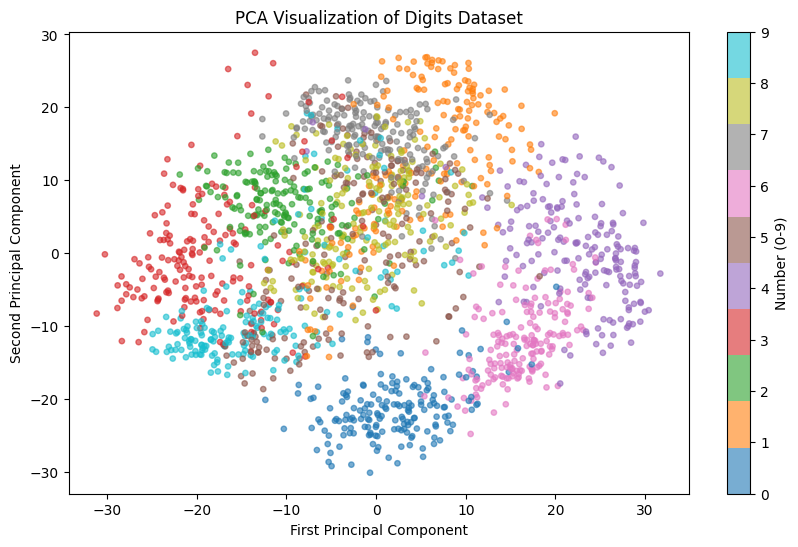

explained_variance_ratio: 0.7382267688459531


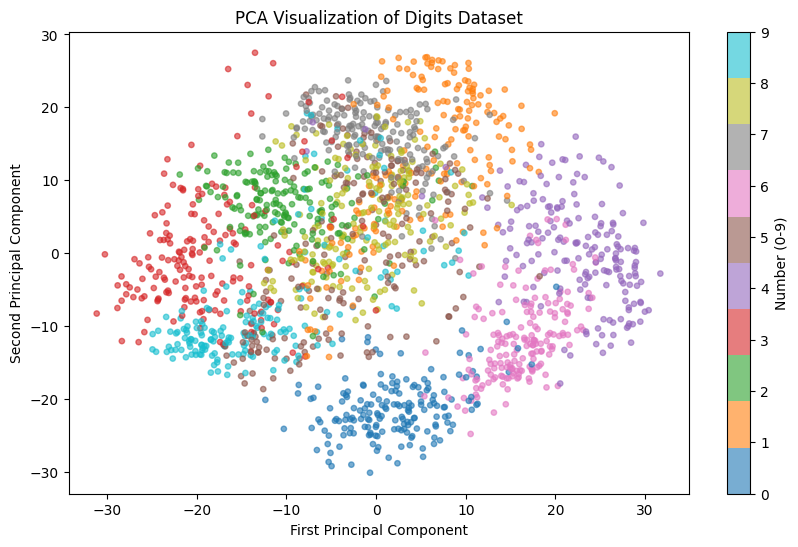

In [8]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

digits = load_digits()
X, y = digits.data, digits.target #digit data

#Scaling with standardscaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

def run_pca_pipeline(X,n_components=2):
  """
  요구사항:
  - StandardScaler로 X를 스케일링한다.
  - sklearn.decomposition.PCA(n_components)로 fit_transform한다.
  - 반환값: (X_reduced, explained_variance_ratio) 튜플.
  - 별도로 시각화 함수를 만들어, X_reduced를 라벨(y)별로 색을 다르게 해서
    scatter plot으로 그리고 'week01/pca_digits.png'로 저장한다.
  """


  #PCA (return : tupel(X_reduced, explained_variance_ratio))
  pca = PCA(n_components)
  X_reduced, explained_variance_ratio  = pca.fit_transform(X), pca.explained_variance_ratio_
  print(f"explained_variance_ratio: {sum(explained_variance_ratio)}")
  #Visualization
  plt.figure(figsize=(10, 6))
  scatter = plt.scatter(X_reduced[:,0],X_reduced[:,1],c=y, cmap='tab10', alpha=0.6, s=15)
  plt.colorbar(scatter, label="Number (0-9)")
  plt.xlabel("First Principal Component")
  plt.ylabel("Second Principal Component")
  plt.title("PCA Visualization of Digits Dataset")
  plt.savefig("pca_digits.png")
  plt.show()
run_pca_pipeline(X,2)
run_pca_pipeline(X,10)
